In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from tqdm import tqdm
import os
import gc

In [19]:
def generate_class_scatter_pdf_optimized():
    """
    优化版本：生成包含每个class_name散点图的PDF文件
    """
    # 读取数据
    print("正在读取数据...")
    clustering_results = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/clustering_results.csv")
    tsne_features = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/tsne_features.csv")
    
    # 确保数据对齐
    assert len(clustering_results) == len(tsne_features), "数据长度不匹配"
    
    # 获取所有唯一的class_name
    unique_classes = sorted(clustering_results['class_name'].unique())
    print(f"找到 {len(unique_classes)} 个不同的类别")
    
    # 设置matplotlib参数
    plt.rcParams['figure.figsize'] = (12, 10)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    
    # 设置中文字体支持
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 创建PDF文件
    output_path = "/media/ubuntu/sda/visual_stimuli_pattern/dynamic/class_scatter_plots_optimized.pdf"
    
    # 预计算坐标范围
    x_min, x_max = tsne_features['tSNE1'].min() - 5, tsne_features['tSNE1'].max() + 5
    y_min, y_max = tsne_features['tSNE2'].min() - 5, tsne_features['tSNE2'].max() + 5
    total_points = len(clustering_results)
    
    with PdfPages(output_path) as pdf:
        for i, class_name in enumerate(tqdm(unique_classes, desc="生成散点图")):
            fig, ax = plt.subplots(figsize=(12, 10))
            
            current_class_mask = clustering_results['class_name'] == class_name
            other_class_mask = ~current_class_mask
            
            if other_class_mask.sum() > 0:
                ax.scatter(tsne_features.loc[other_class_mask, 'tSNE1'],
                          tsne_features.loc[other_class_mask, 'tSNE2'],
                          c='lightgray', alpha=0.2, s=0.5, label=f'Other classes ({other_class_mask.sum():,} points)')
            
            # 绘制当前类别的点（彩色）
            if current_class_mask.sum() > 0:
                ax.scatter(tsne_features.loc[current_class_mask, 'tSNE1'],
                          tsne_features.loc[current_class_mask, 'tSNE2'],
                          c='red', alpha=0.8, s=4, label=f'{class_name} ({current_class_mask.sum():,} points)')
            
            # 设置图形属性
            ax.set_xlabel('t-SNE Dimension 1', fontsize=14)
            ax.set_ylabel('t-SNE Dimension 2', fontsize=14)
            ax.set_title(f'Class: {class_name}', fontsize=16, fontweight='bold')
            ax.grid(False)
            
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            
            pdf.savefig(fig, bbox_inches='tight', dpi=200)  # 降低DPI以提高性能
            plt.close(fig)
            
            # 定期清理内存
            if (i + 1) % 50 == 0:
                gc.collect()
    
    print(f"\nPDF文件已生成: {output_path}")
    print(f"总共包含 {len(unique_classes)} 页散点图")
    
generate_class_scatter_pdf_optimized()

正在读取数据...
找到 1854 个不同的类别


生成散点图: 100%|██████████| 1854/1854 [05:33<00:00,  5.55it/s]



PDF文件已生成: /media/ubuntu/sda/visual_stimuli_pattern/dynamic/class_scatter_plots_optimized.pdf
总共包含 1854 页散点图


In [3]:
clustering_results = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/clustering_results.csv")
tsne_features = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/tsne_features.csv")

In [4]:
a = pd.crosstab(clustering_results['kmeans_cluster'], clustering_results['class_name'])

In [5]:
a[a < 10] = 0
a[a >= 10] = 1

In [21]:
a.columns[np.where(a.iloc[4, :] == 1)[0]]

Index(['aircraft_carrier', 'cruise_ship', 'ferry', 'hovercraft', 'jet',
       'missile', 'rocket', 'sailboat', 'satellite', 'shark', 'ship',
       'space_shuttle', 'speedboat', 'tugboat', 'whale', 'yacht'],
      dtype='object', name='class_name')

<Axes: xlabel='tSNE1', ylabel='tSNE2'>

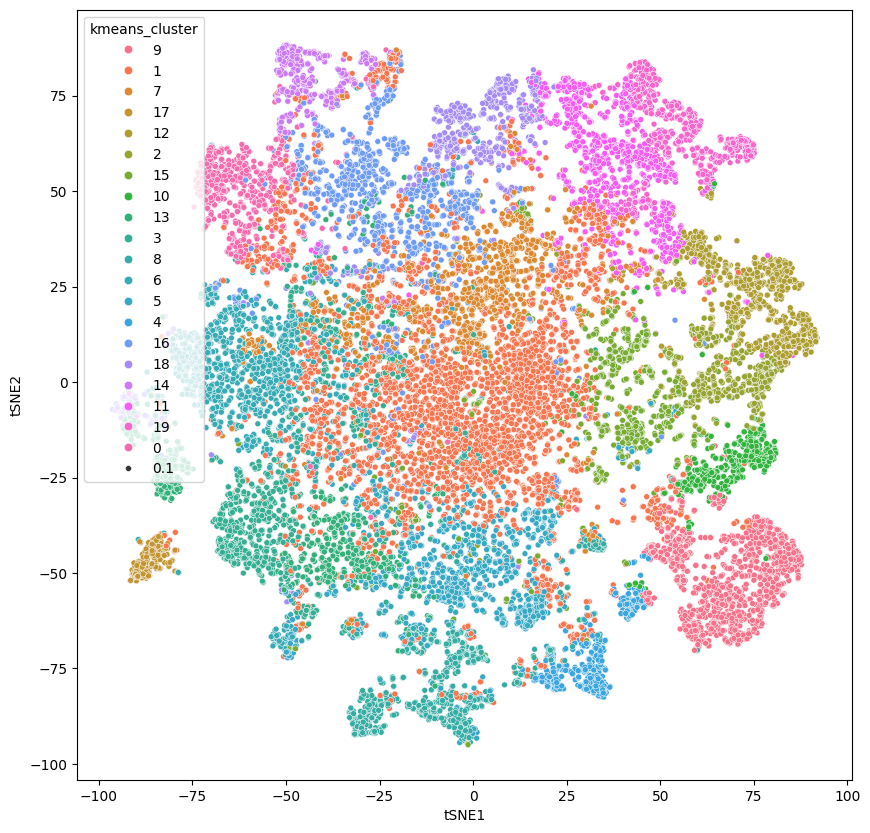

In [14]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x = tsne_features['tSNE1'],
                y = tsne_features['tSNE2'],
                hue = clustering_results['kmeans_cluster'].astype(str),
                size = 0.1)


In [16]:
def generate_cluster_scatter_pdf():
    """
    为每个k-means cluster生成一页散点图的PDF文件
    每个页面显示该cluster的高亮点和所有其他cluster的浅灰色点
    """
    # 读取数据
    print("正在读取数据...")
    clustering_results = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/clustering_results.csv")
    tsne_features = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/dynamic/tsne_features.csv")
    
    # 确保数据对齐
    assert len(clustering_results) == len(tsne_features), "数据长度不匹配"
    
    # 获取所有唯一的k-means cluster
    unique_clusters = sorted(clustering_results['kmeans_cluster'].unique())
    print(f"找到 {len(unique_clusters)} 个不同的cluster")
    
    # 设置matplotlib参数
    plt.rcParams['figure.figsize'] = (12, 10)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    
    # 创建PDF文件
    output_path = "/media/ubuntu/sda/visual_stimuli_pattern/dynamic/cluster_scatter_plots.pdf"
    
    # 预计算坐标范围
    x_min, x_max = tsne_features['tSNE1'].min() - 5, tsne_features['tSNE1'].max() + 5
    y_min, y_max = tsne_features['tSNE2'].min() - 5, tsne_features['tSNE2'].max() + 5
    total_points = len(clustering_results)
    
    print(f"开始生成PDF...")
    print(f"每个页面将显示一个cluster高亮为红色，其他cluster为浅灰色")
    
    with PdfPages(output_path) as pdf:
        for i, cluster_id in enumerate(tqdm(unique_clusters, desc="生成cluster散点图")):
            # 创建新图形
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # 获取当前cluster的数据
            current_cluster_mask = clustering_results['kmeans_cluster'] == cluster_id
            other_cluster_mask = ~current_cluster_mask
            
            # 绘制其他cluster的点（浅灰色）
            if other_cluster_mask.sum() > 0:
                ax.scatter(tsne_features.loc[other_cluster_mask, 'tSNE1'],
                          tsne_features.loc[other_cluster_mask, 'tSNE2'],
                          c='lightgray', alpha=0.3, s=1, 
                          label=f'Other clusters ({other_cluster_mask.sum():,} points)')
            
            # 绘制当前cluster的点（红色）
            if current_cluster_mask.sum() > 0:
                ax.scatter(tsne_features.loc[current_cluster_mask, 'tSNE1'],
                          tsne_features.loc[current_cluster_mask, 'tSNE2'],
                          c='red', alpha=0.8, s=3, 
                          label=f'Cluster {cluster_id} ({current_cluster_mask.sum():,} points)')
            
            # 设置图形属性
            ax.set_xlabel('t-SNE Dimension 1', fontsize=14)
            ax.set_ylabel('t-SNE Dimension 2', fontsize=14)
            ax.set_title(f'K-means Cluster: {cluster_id}', fontsize=16, fontweight='bold')
            ax.legend(fontsize=12)
            ax.grid(True, alpha=0.3)
            
            # 设置坐标轴范围
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            
            # 添加统计信息
            cluster_points = current_cluster_mask.sum()
            percentage = (cluster_points / total_points) * 100
            
            info_text = f'Total points: {total_points:,}\nCluster {cluster_id}: {cluster_points:,}\nPercentage: {percentage:.2f}%'
            ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            # 保存到PDF
            pdf.savefig(fig, bbox_inches='tight', dpi=200)
            plt.close(fig)
            
            # 定期清理内存
            if (i + 1) % 5 == 0:
                gc.collect()
                print(f"已完成 {i + 1}/{len(unique_clusters)} 个cluster")
    
    print(f"\nPDF文件已生成: {output_path}")
    print(f"总共包含 {len(unique_clusters)} 页散点图")
    
    # 显示文件大小
    file_size = os.path.getsize(output_path) / (1024 * 1024)  # MB
    print(f"文件大小: {file_size:.2f} MB")

# 运行函数
generate_cluster_scatter_pdf()


正在读取数据...
找到 20 个不同的cluster
开始生成PDF...
每个页面将显示一个cluster高亮为红色，其他cluster为浅灰色


生成cluster散点图:  25%|██▌       | 5/20 [00:01<00:03,  4.28it/s]

已完成 5/20 个cluster


生成cluster散点图:  50%|█████     | 10/20 [00:02<00:02,  4.26it/s]

已完成 10/20 个cluster


生成cluster散点图:  75%|███████▌  | 15/20 [00:03<00:01,  4.24it/s]

已完成 15/20 个cluster


生成cluster散点图: 100%|██████████| 20/20 [00:04<00:00,  4.42it/s]

已完成 20/20 个cluster

PDF文件已生成: /media/ubuntu/sda/visual_stimuli_pattern/dynamic/cluster_scatter_plots.pdf
总共包含 20 页散点图
文件大小: 6.65 MB
